# 03 - what the frozen features look like on the new domains (GPU)

Descriptive, after notebook 02, trains nothing and changes no result. The same views as part
one's notebook 14, for every dataset and both encoders at their pre-registered layers, on the TEST
split, with the same input as the run (channel statistics from notebook 02's info files).

1. Embedding maps. PCA 1-3 of two test chips' patch features as colours, and k-means clusters.
2. Similarity search by example. One query patch of the target class, its similarity map on the
   chip, and which classes the most similar pure patches of the whole test split belong to.
3. Class distances. For every pure test patch, how much closer it is to its own class centre
   than to the nearest other one, as histograms and a ranking AUC per class (1 = fully apart).
4. AnyUp versions (last cell). Views 1-3 again on the features after AnyUp upsampling to 4 px
   blocks (as part one), same chips and query spot, AUCs next to the raw ones in the same CSV.

The chips, the query patch and the purity rule are fixed in `src/sartransfer/domains/embed_views.py`
(set before any view was looked at, from the labels only). Centres come from the test split's own
labels, so the AUCs are optimistic and describe the features, not a model.

**Runtime** - A100 with High-RAM (the same as 02), about 12 min for the views plus setup (measured 2026-09-29, raw views 7 min, AnyUp views 5 min). Run all cells in order. Figures
and `embedding_numbers.csv` go to Drive `MyDrive/sar-transfer-part2/embeddings/`.

In [1]:
# --- cell - mount Google Drive ---
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# <<<SARTRANSFER-SYNC-BEGIN>>>
# Empty sync cell: published notebooks carry no packed code. On your own machine,
# in the repository folder, run   python sync.py   and open the notebook again;
# this cell then holds the package source and unpacks it on the runtime.
raise RuntimeError("The sync cell is empty. On your own machine, in the repository folder, "
                   "run:  python sync.py  and reopen this notebook.")
# <<<SARTRANSFER-SYNC-END>>>

In [ ]:
# --- cell - secrets, GPU, RAM, prepared data to local disk ---
import os, shutil, time
from pathlib import Path
import psutil, torch
from sartransfer.env import load_env, require, model_cache_on_drive

load_env(keys=("HF_TOKEN",))                       # the read token only; the write token never enters this runtime
require("HF_TOKEN", "gated model weights")
model_cache_on_drive()
assert torch.cuda.is_available(), "switch to a GPU runtime"
g = torch.cuda.get_device_properties(0)
print(f"gpu: {g.name} | GPU memory {g.total_memory / 1e9:.0f} GB | system RAM {psutil.virtual_memory().total / 1e9:.0f} GB")
DRIVE = Path("/content/drive/MyDrive/sar-transfer-part2")  # part two: converted data + results;
                                                          # .env and hf_cache stay in MyDrive/sar-transfer
RES = DRIVE / "results"
PREP = Path("/content/domains_prepared")           # local disk: a few large files per dataset
from sartransfer.domains import hub
HF_OWNER = "saverin00"                             # your Hugging Face account with the private copies; None = Drive only
# 1st your private Hugging Face copy (fast), used only if it is the same conversion as the one on
# Drive and HF_TOKEN can read it; else the Drive copy. Only complete copies are accepted.
DATASETS = sorted(hub.stage(("glacial_lakes", "snow", "forty_v1", "glavitu_alp"), PREP, DRIVE / "domains",
                            owner=HF_OWNER, token=os.environ["HF_TOKEN"]))
print("prepared datasets:", DATASETS, "| free disk", f"{shutil.disk_usage('/content').free / 1e9:.0f} GB")

In [4]:
# --- cell - VIEWS -- every dataset x both encoders, figures + numbers to Drive ---
from sartransfer.domains.embed_views import run_all

OUT = DRIVE / "embeddings"
t0 = time.perf_counter()
table = run_all(PREP, RES, OUT, DATASETS, token=os.environ["HF_TOKEN"])
print(f"done in {(time.perf_counter() - t0) / 60:.1f} min")
print(table.round(3).to_string(index=False))

Loading weights:   0%|          | 0/415 [00:01<?, ?it/s]

dinov3-l-sat: 303.1 M parameters loaded
forty_v1 x satellite DINOv3: chips [195, 300], query built mean AUC 0.888
glacial_lakes x satellite DINOv3: chips [1502, 890], query lake mean AUC 0.911
glavitu_alp x satellite DINOv3: chips [10, 14], query glacier mean AUC 0.795
snow x satellite DINOv3: chips [1247, 1090], query snow mean AUC 0.691
installing ['open_clip_torch']


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 26 files:   0%|          | 0/26 [00:00<?, ?it/s]

remote code verified: 26 files == reviewed copy (nvidia/C-RADIOv4-H@0057b339059c)


Loading weights:   0%|          | 0/390 [00:00<?, ?it/s]

cradio-v4-h: 651.6 M parameters loaded
forty_v1 x C-RADIO: chips [195, 300], query built mean AUC 0.867
glacial_lakes x C-RADIO: chips [1502, 890], query lake mean AUC 0.909
glavitu_alp x C-RADIO: chips [10, 14], query glacier mean AUC 0.757
snow x C-RADIO: chips [1247, 1090], query snow mean AUC 0.624
forty_v1: 31 single-panel images in /content/drive/MyDrive/sar-transfer-part2/embeddings/panels/forty_v1
saved /content/drive/MyDrive/sar-transfer-part2/embeddings/embed_maps_forty_v1.png
saved /content/drive/MyDrive/sar-transfer-part2/embeddings/embed_similarity_forty_v1.png
saved /content/drive/MyDrive/sar-transfer-part2/embeddings/embed_margins_forty_v1.png
glacial_lakes: 19 single-panel images in /content/drive/MyDrive/sar-transfer-part2/embeddings/panels/glacial_lakes
saved /content/drive/MyDrive/sar-transfer-part2/embeddings/embed_maps_glacial_lakes.png
saved /content/drive/MyDrive/sar-transfer-part2/embeddings/embed_similarity_glacial_lakes.png
saved /content/drive/MyDrive/sar-tra

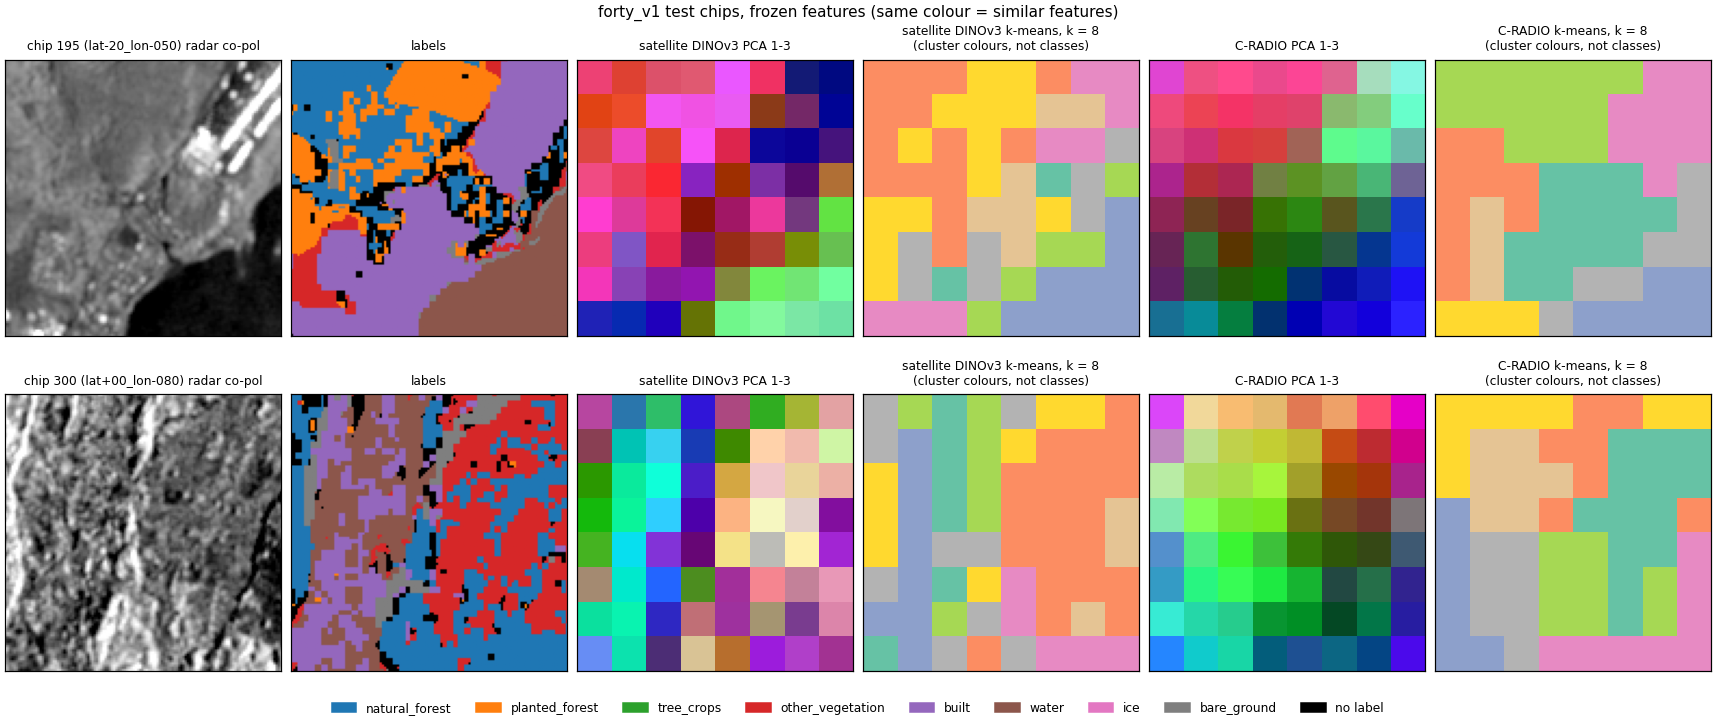

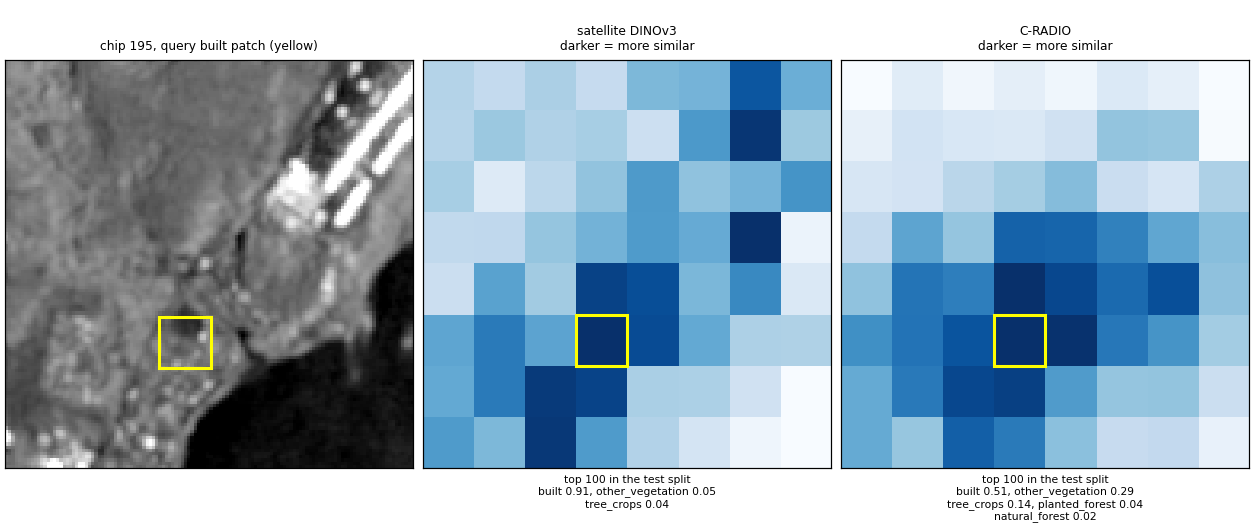

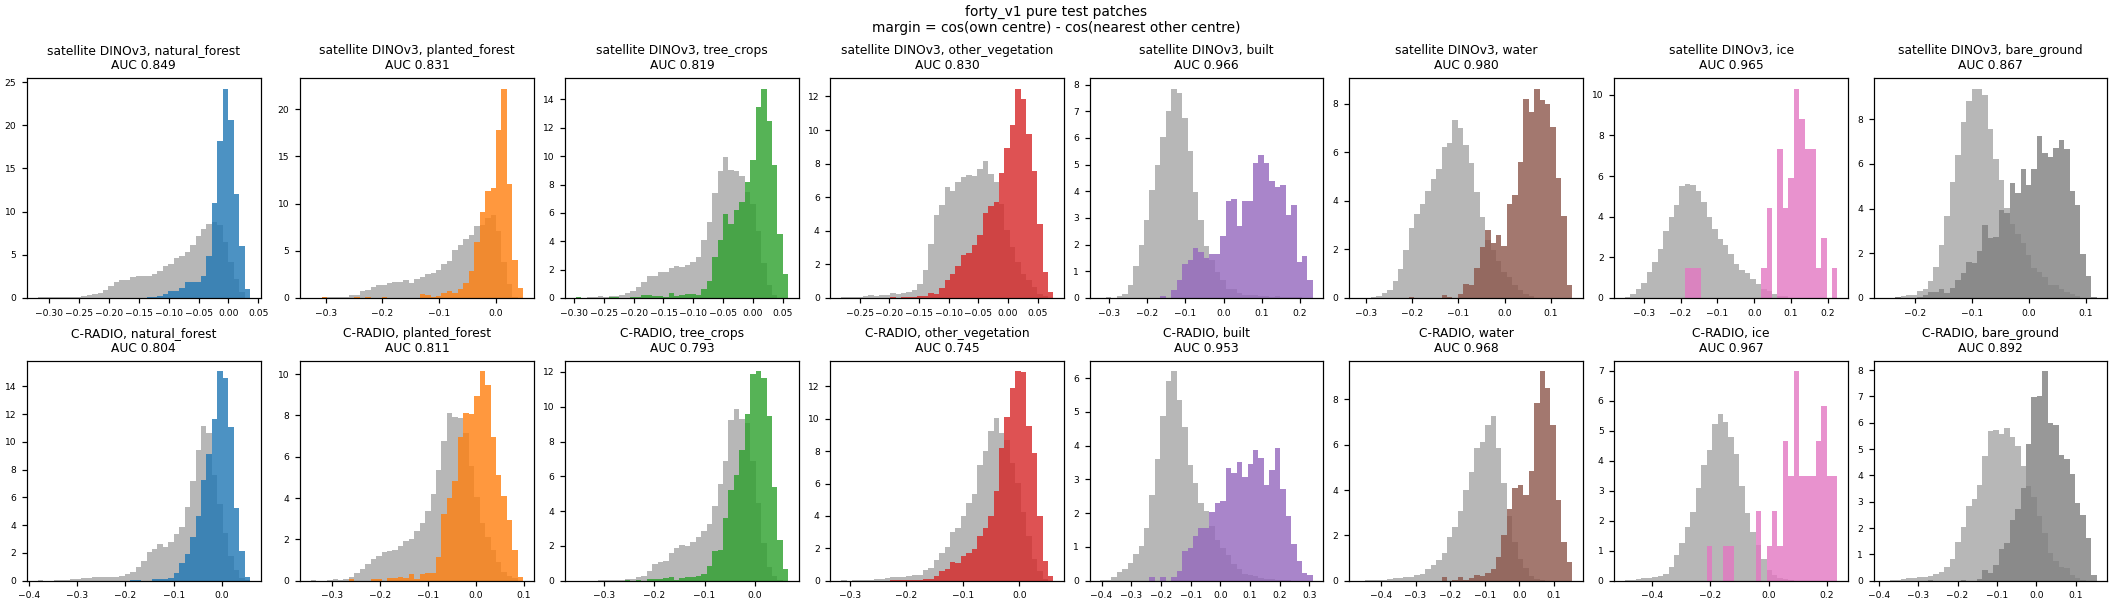

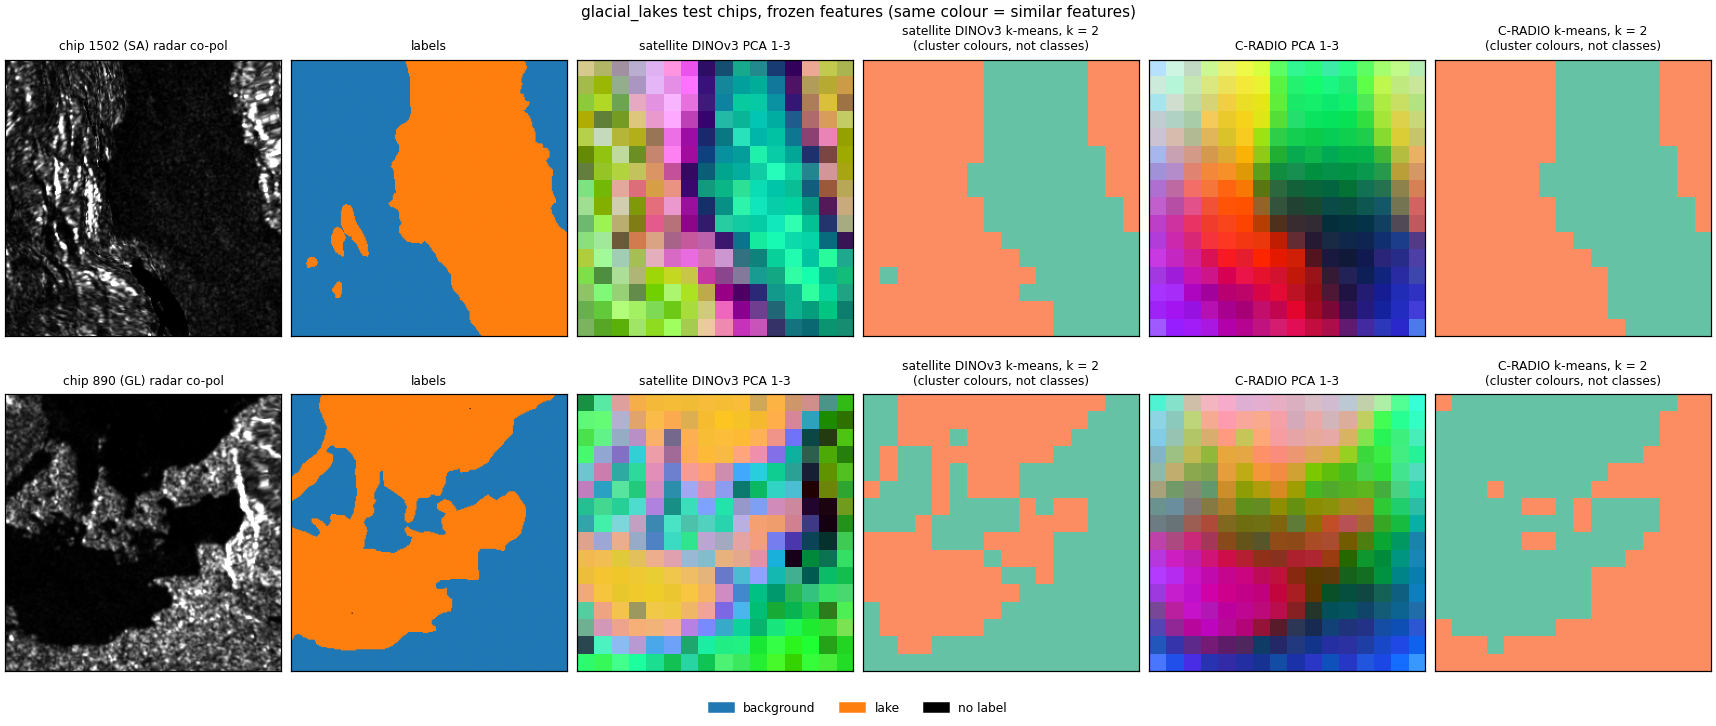

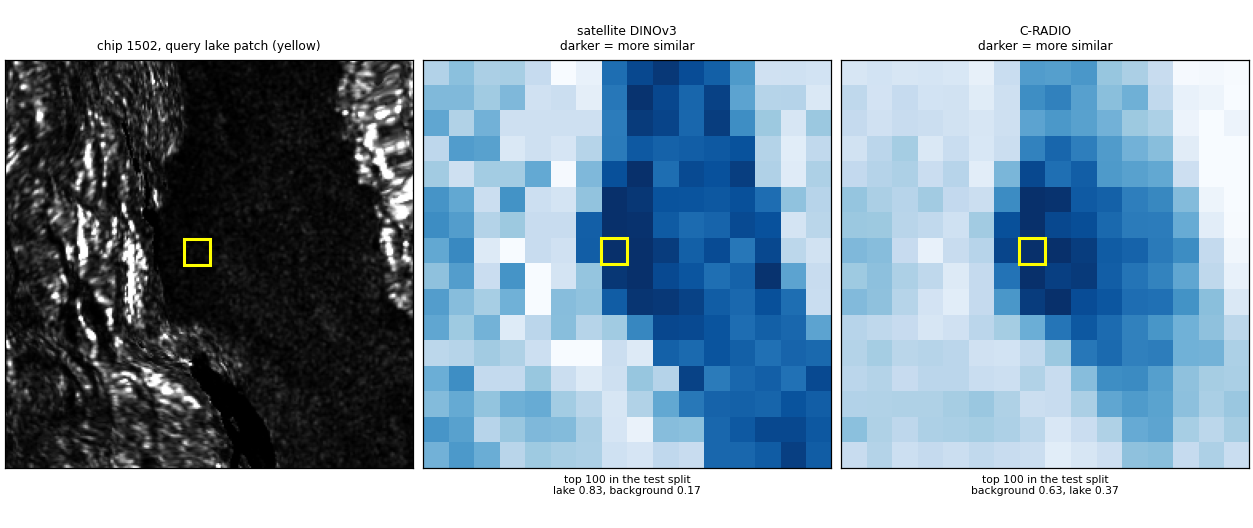

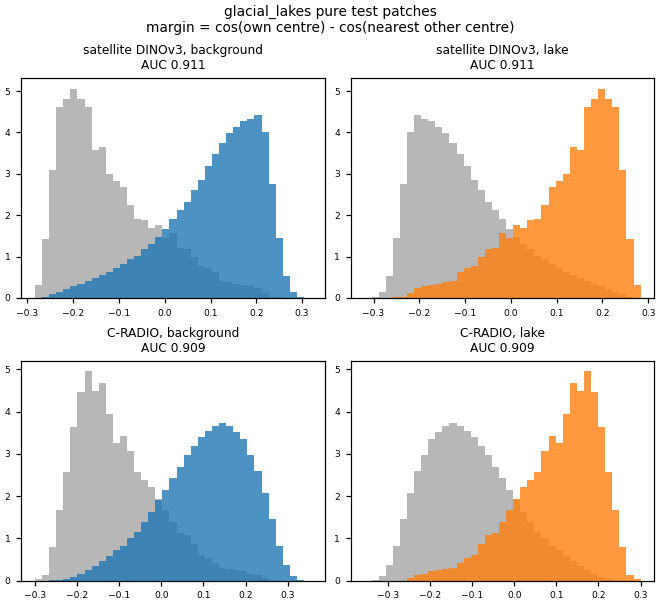

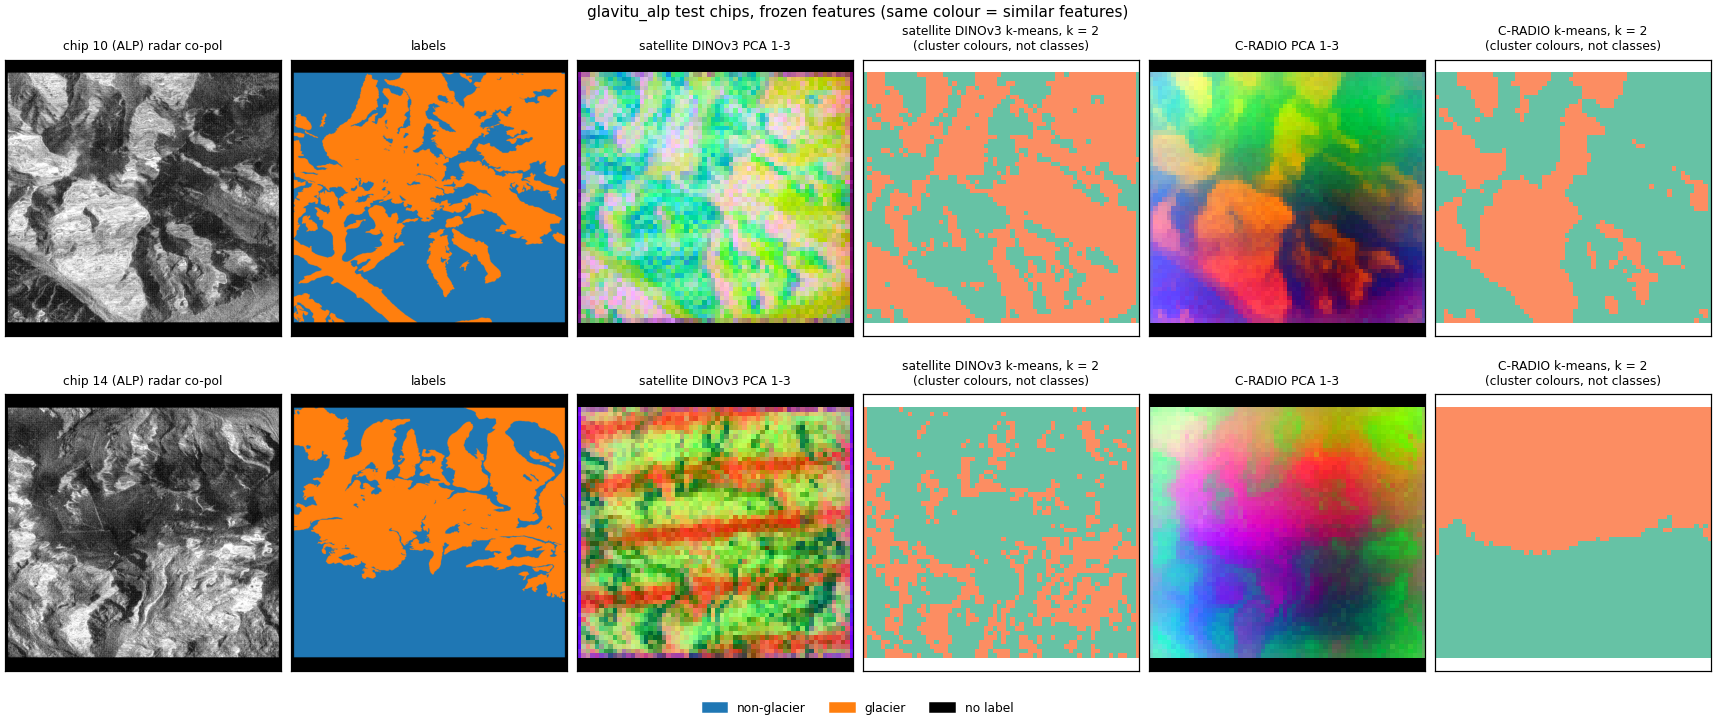

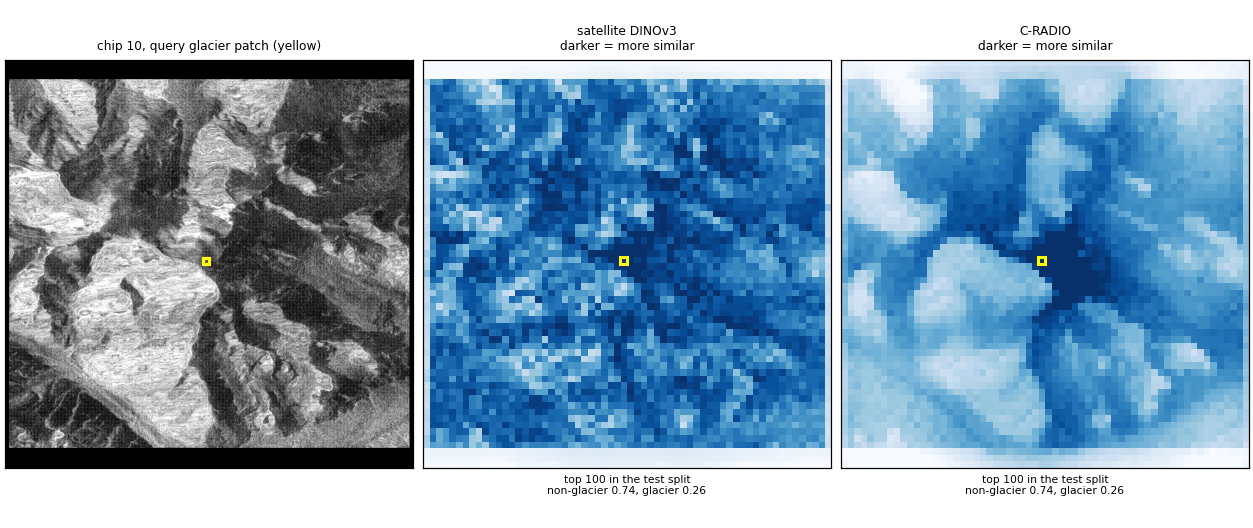

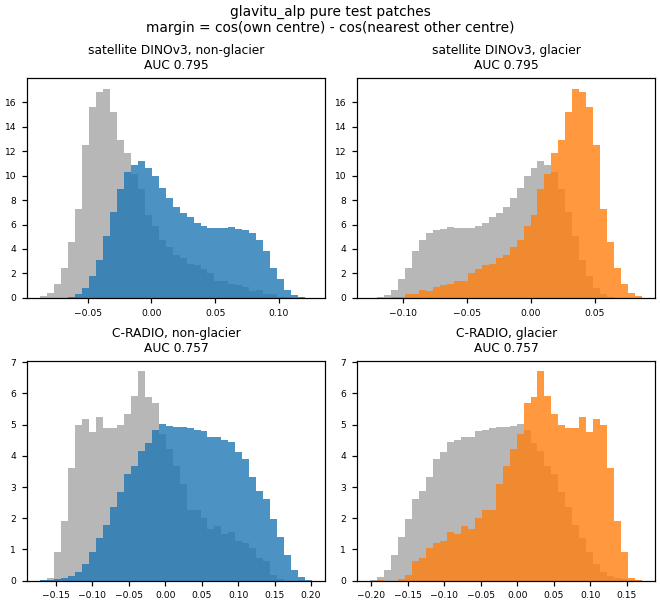

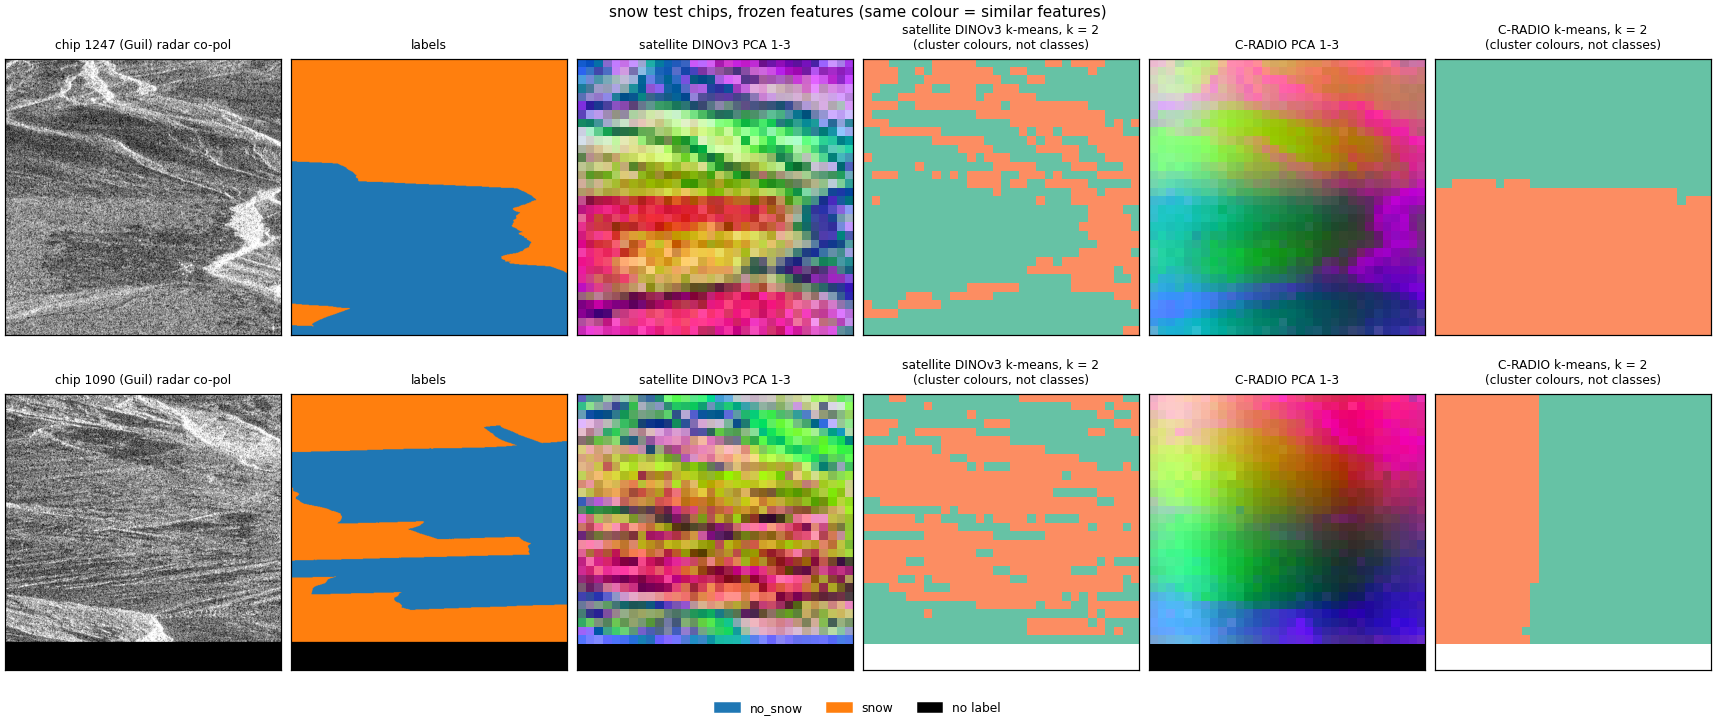

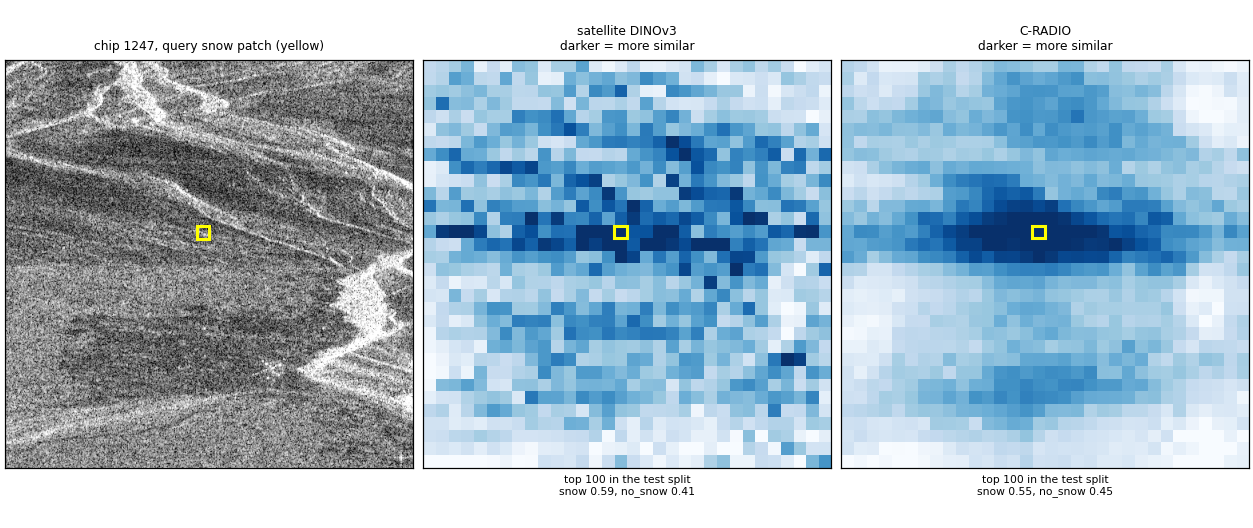

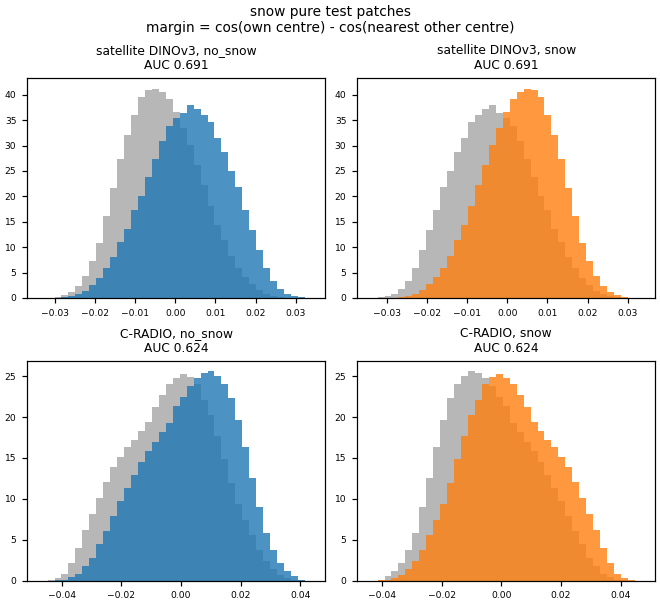

In [5]:
# --- cell - SHOW -- the figures, dataset by dataset ---
from IPython.display import Image, display

for d in DATASETS:
    for kind in ("maps", "similarity", "margins"):
        display(Image(filename=str(OUT / f"embed_{kind}_{d}.png")))

Loading weights:   0%|          | 0/415 [00:00<?, ?it/s]

dinov3-l-sat: 303.1 M parameters loaded


/usr/local/lib/python3.13/dist-packages/torch/nn/functional.py:2954: UserWarning: Mismatch dtype between input and weight: input dtype = c10::BFloat16, weight dtype = float, Cannot dispatch to fused implementation. (Triggered internally at /pytorch/aten/src/ATen/native/layer_norm.cpp:344.)
  return torch.rms_norm(input, normalized_shape, weight, eps)


forty_v1 x satellite DINOv3 AnyUp: top 1600 blocks, mean AUC 0.870 (AUC sample 400,000 blocks)
glacial_lakes x satellite DINOv3 AnyUp: top 1600 blocks, mean AUC 0.886 (AUC sample 400,000 blocks)
glavitu_alp x satellite DINOv3 AnyUp: top 1600 blocks, mean AUC 0.754 (AUC sample 400,000 blocks)
snow x satellite DINOv3 AnyUp: top 1600 blocks, mean AUC 0.738 (AUC sample 400,000 blocks)


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 26 files:   0%|          | 0/26 [00:00<?, ?it/s]

remote code verified: 26 files == reviewed copy (nvidia/C-RADIOv4-H@0057b339059c)


Loading weights:   0%|          | 0/390 [00:00<?, ?it/s]

cradio-v4-h: 651.6 M parameters loaded
forty_v1 x C-RADIO AnyUp: top 1600 blocks, mean AUC 0.849 (AUC sample 400,000 blocks)
glacial_lakes x C-RADIO AnyUp: top 1600 blocks, mean AUC 0.890 (AUC sample 400,000 blocks)
glavitu_alp x C-RADIO AnyUp: top 1600 blocks, mean AUC 0.711 (AUC sample 400,000 blocks)
snow x C-RADIO AnyUp: top 1600 blocks, mean AUC 0.628 (AUC sample 400,000 blocks)
forty_v1: 31 single-panel images in /content/drive/MyDrive/sar-transfer-part2/embeddings/panels/forty_v1
saved /content/drive/MyDrive/sar-transfer-part2/embeddings/embed_maps_anyup_forty_v1.png
saved /content/drive/MyDrive/sar-transfer-part2/embeddings/embed_similarity_anyup_forty_v1.png
saved /content/drive/MyDrive/sar-transfer-part2/embeddings/embed_margins_anyup_forty_v1.png
glacial_lakes: 19 single-panel images in /content/drive/MyDrive/sar-transfer-part2/embeddings/panels/glacial_lakes
saved /content/drive/MyDrive/sar-transfer-part2/embeddings/embed_maps_anyup_glacial_lakes.png
saved /content/drive/My

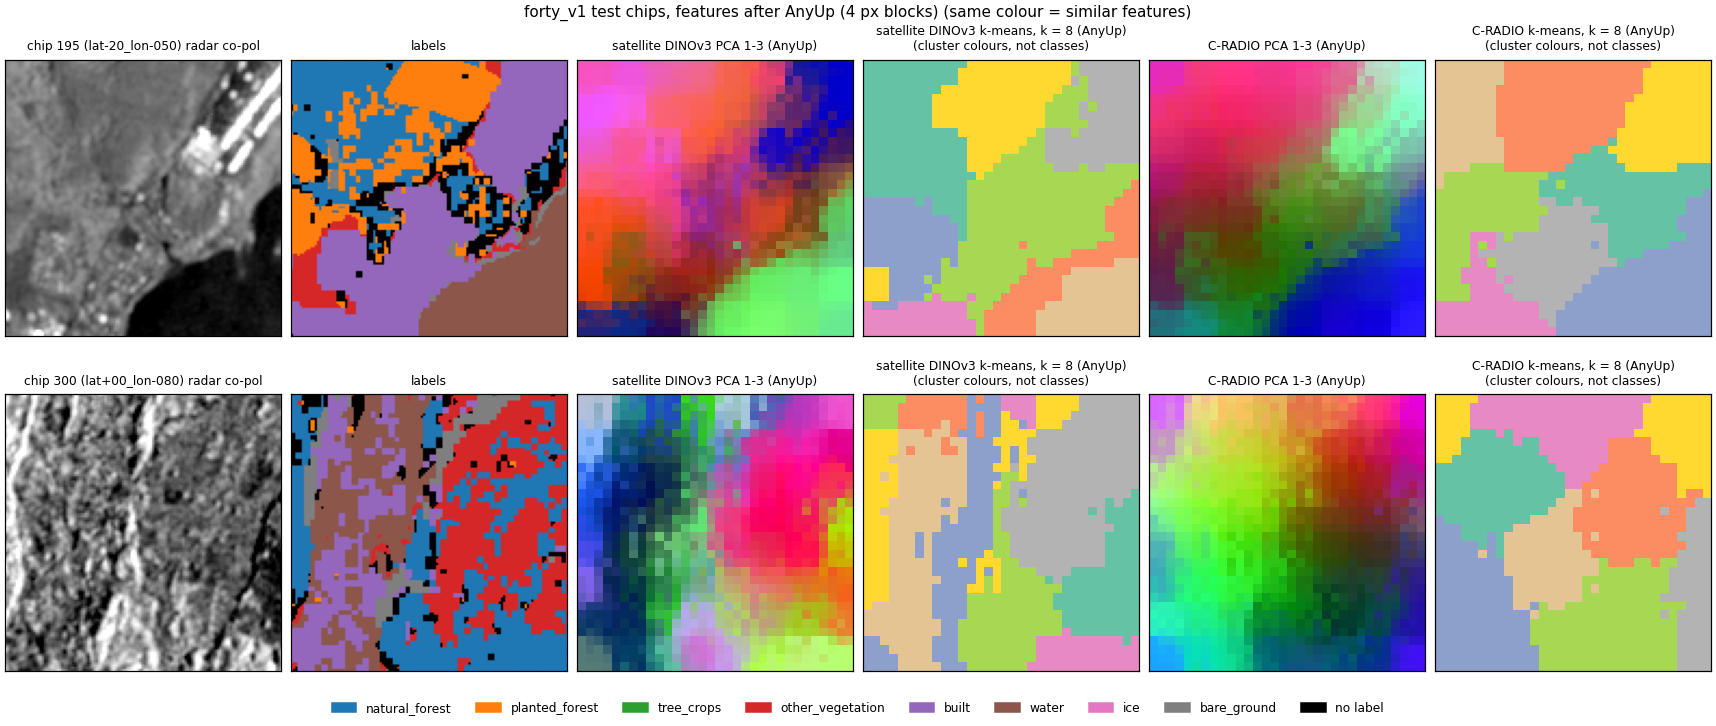

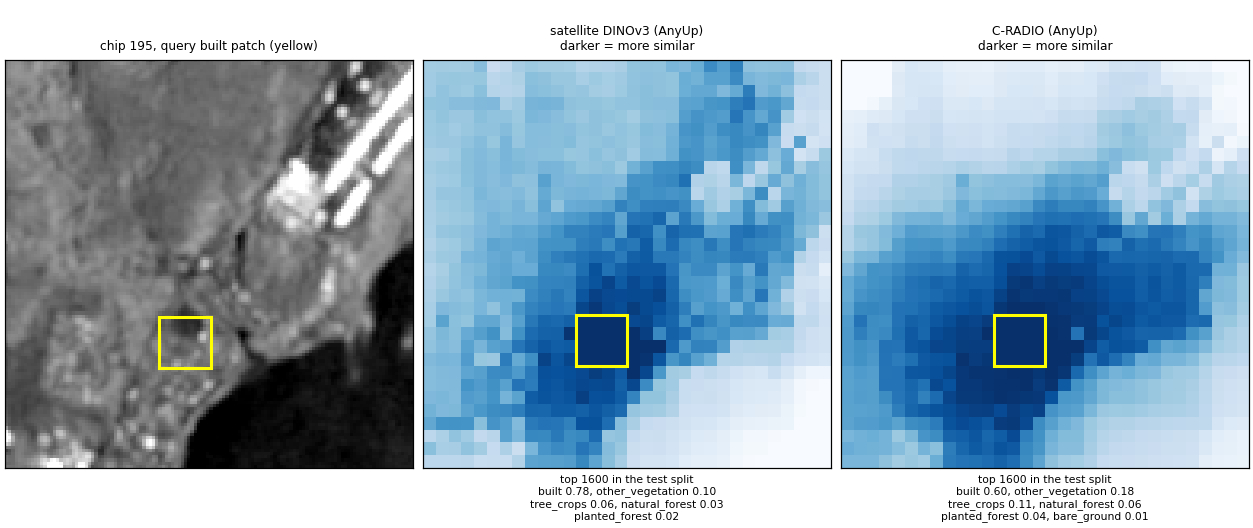

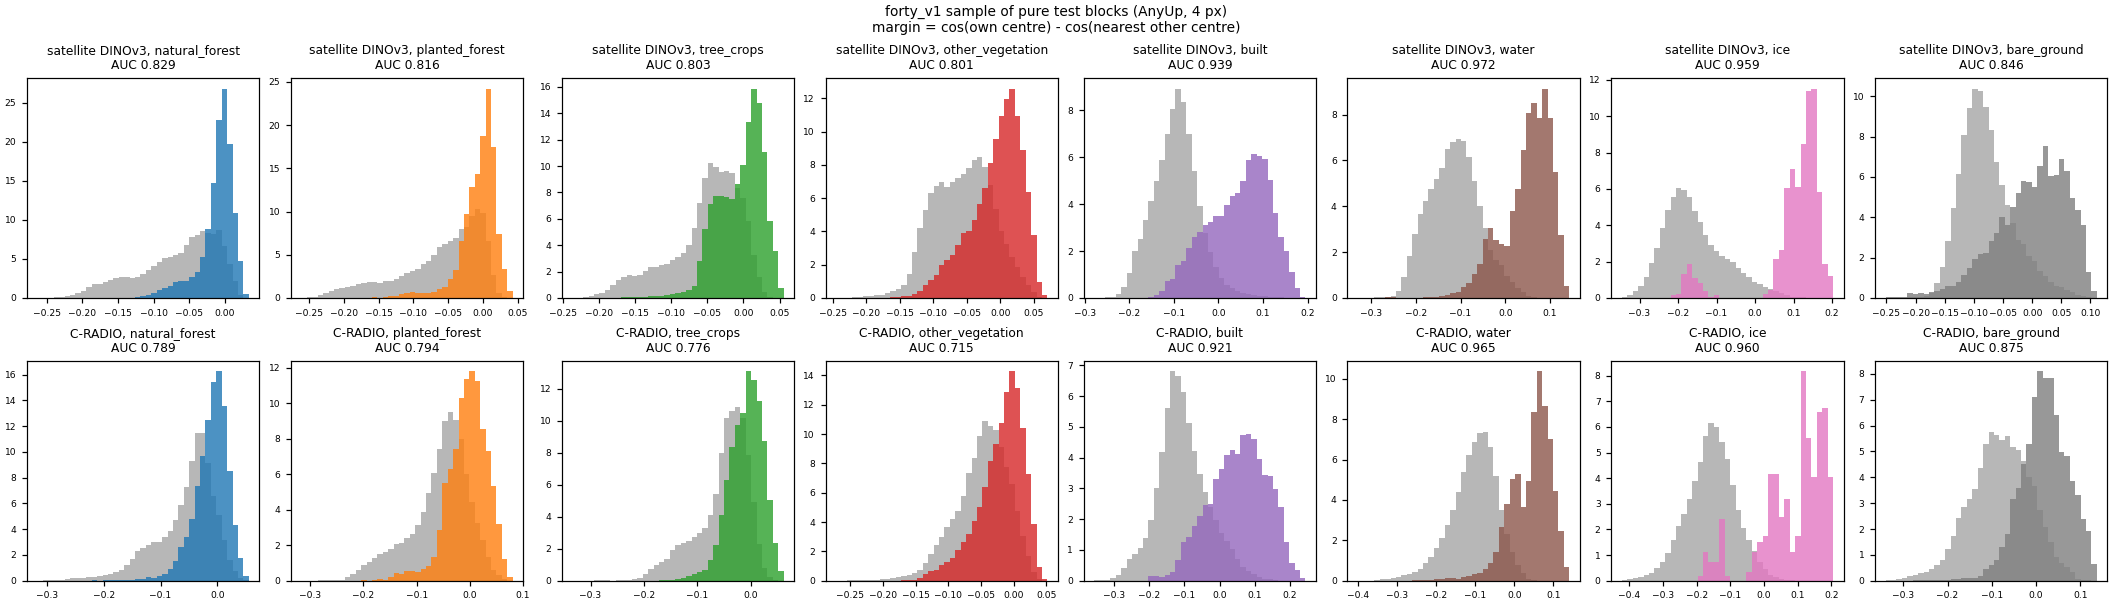

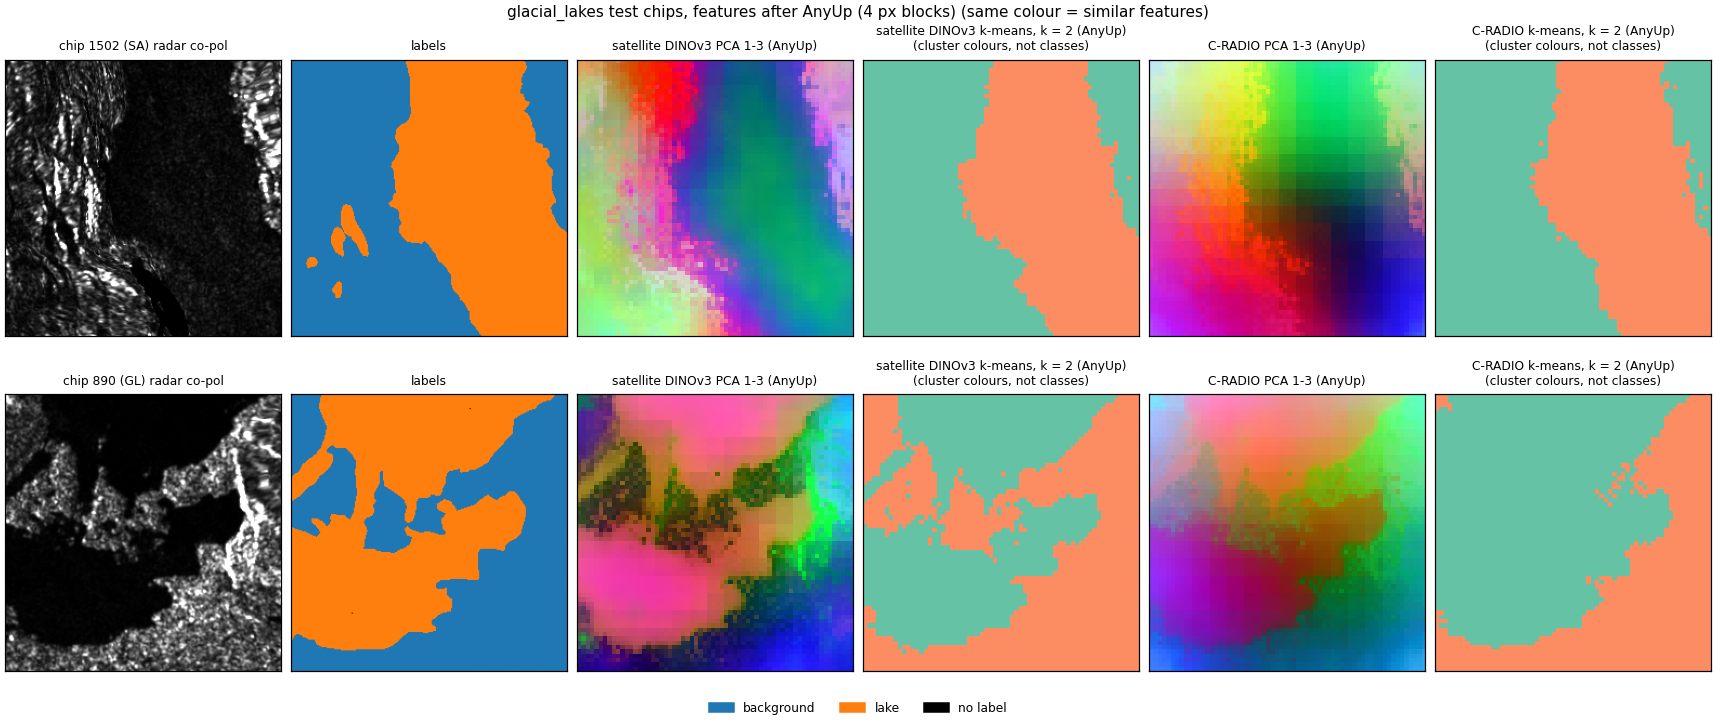

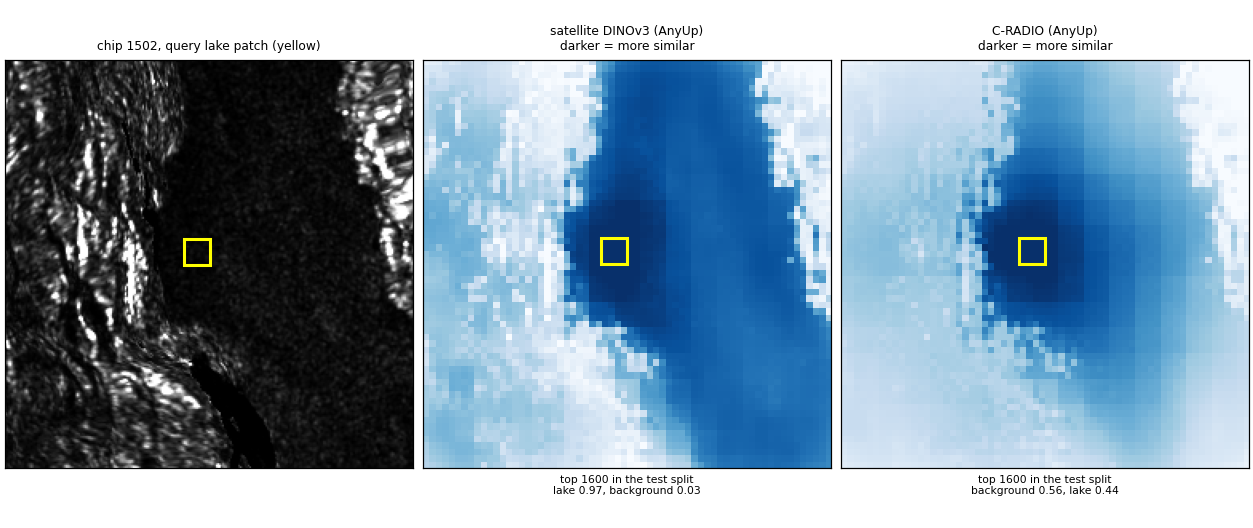

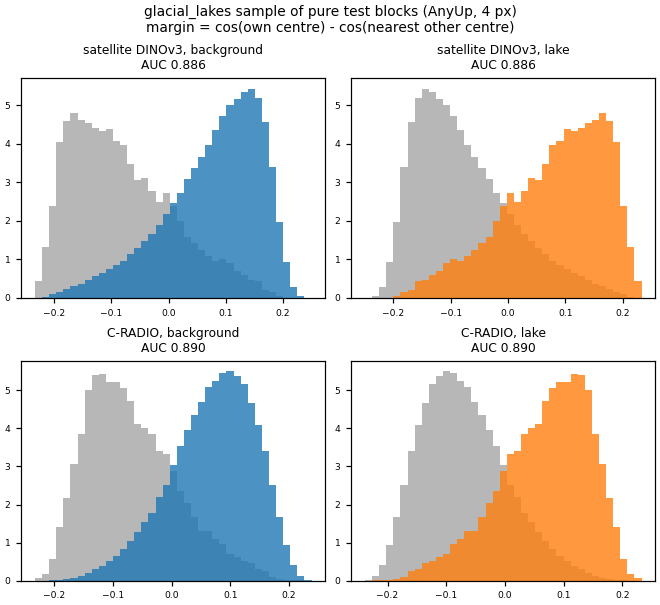

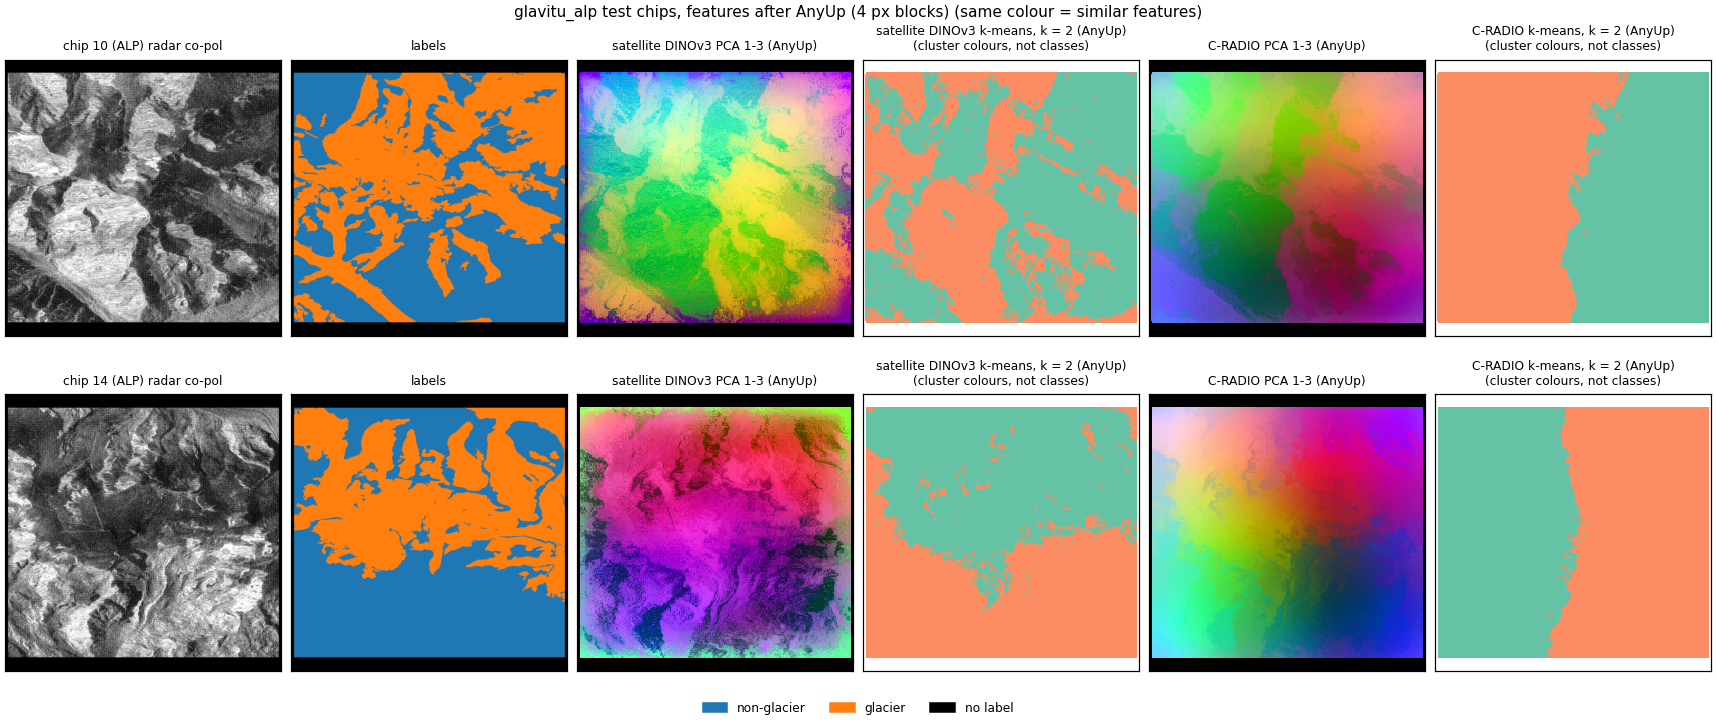

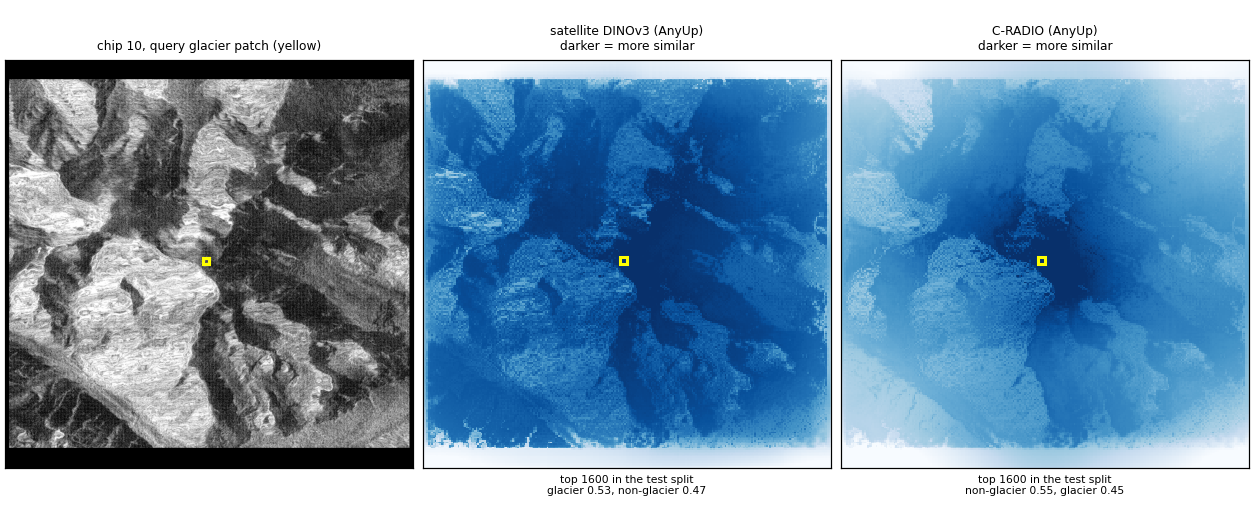

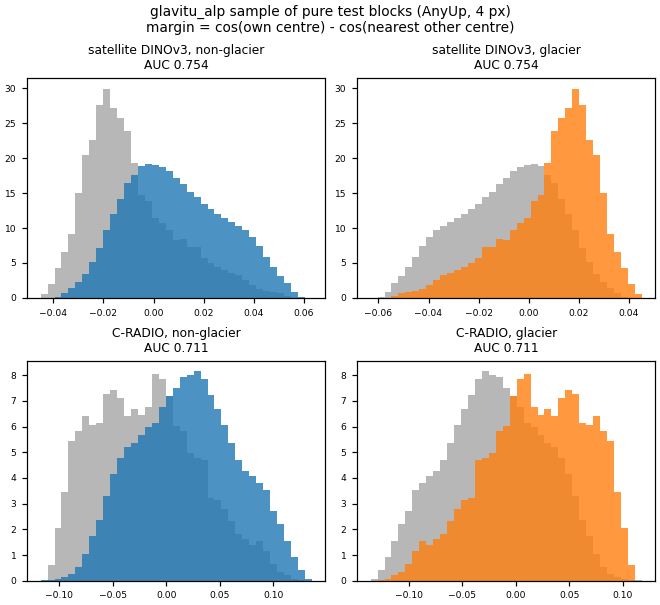

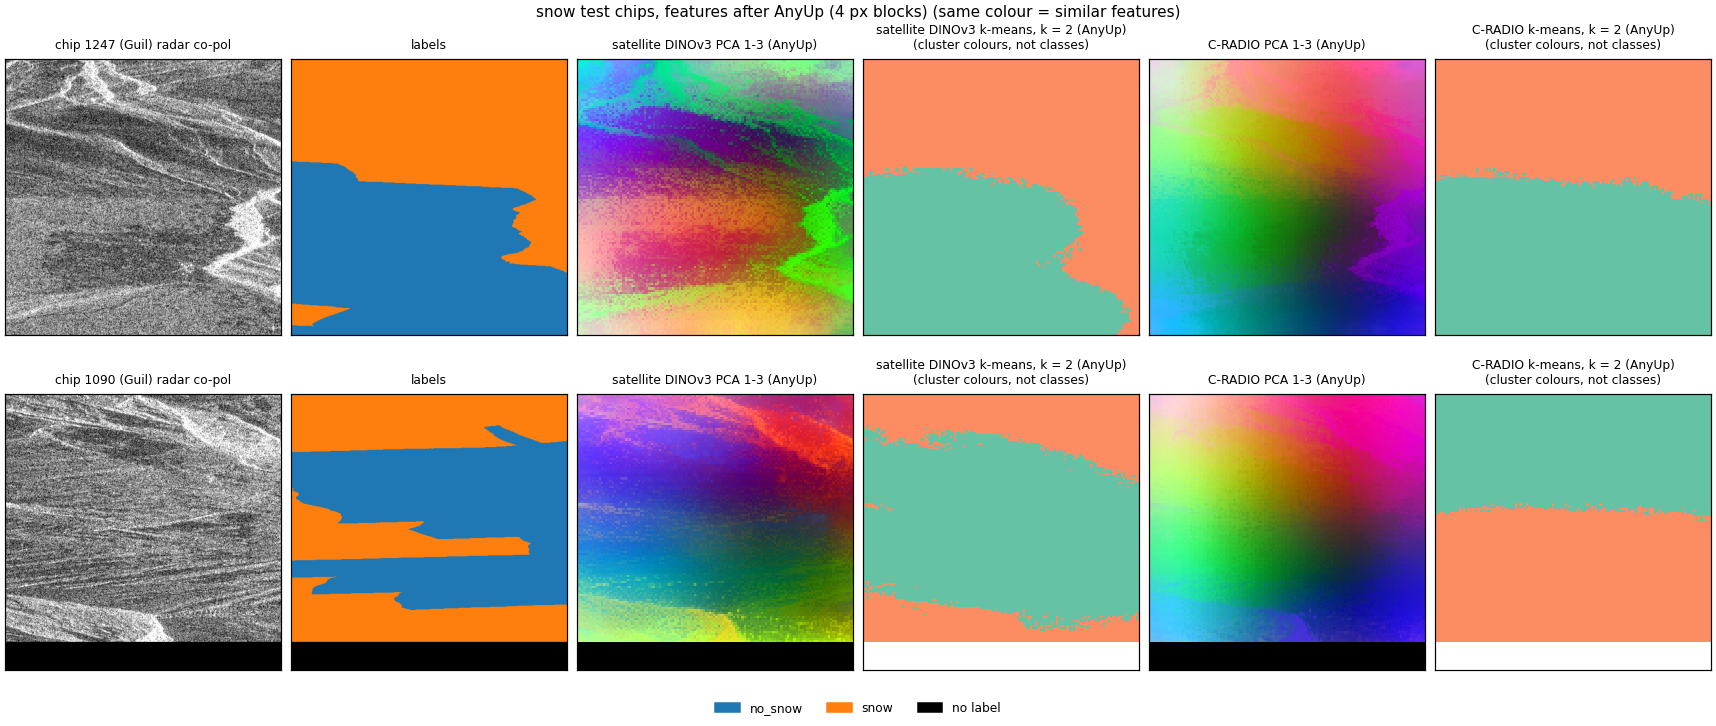

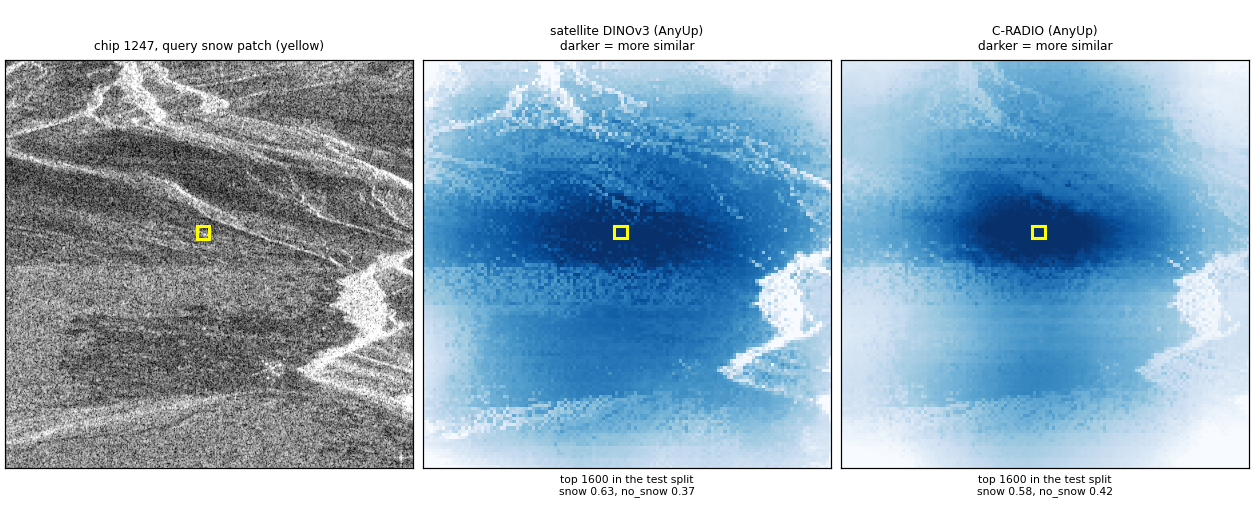

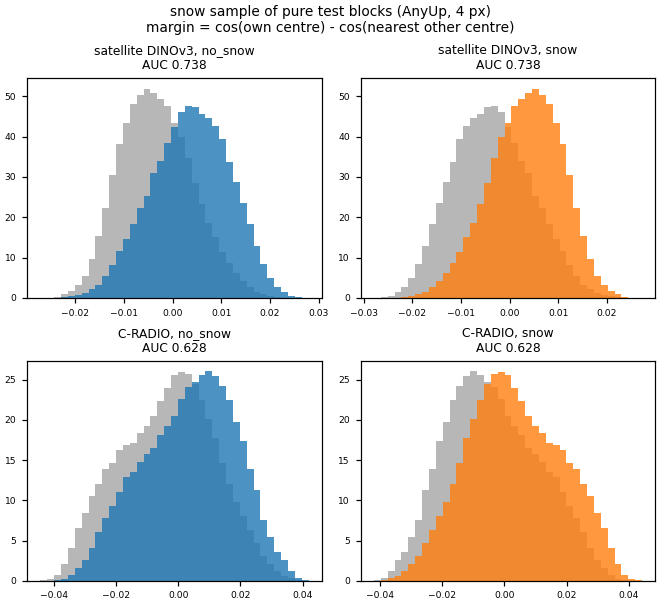

In [6]:
# --- cell - ANYUP -- views 1-3 again on the AnyUp features (4 px blocks), same chips and query spot ---
from IPython.display import Image, display
from sartransfer.domains.embed_views import run_all_anyup

ANYUP = Path("/content/drive/MyDrive/sar-transfer/weights/anyup_multi_backbone.pth")  # part one's copy, sha256-checked
t0 = time.perf_counter()
table = run_all_anyup(PREP, RES, OUT, DATASETS, token=os.environ["HF_TOKEN"], anyup_weights=ANYUP)
print(f"done in {(time.perf_counter() - t0) / 60:.1f} min")
print(table.pivot_table(index=["dataset", "encoder"], columns="features", values="mean_auc").round(3).to_string())
for d in DATASETS:
    for kind in ("maps", "similarity", "margins"):
        display(Image(filename=str(OUT / f"embed_{kind}_anyup_{d}.png")))